# ML Pipeline — CER Porto
## Fase 2: Feature Engineering + XGBoost

Pipeline de Machine Learning integrado com simulação ABM (Mesa 3.x).  
Substitui perfis sintéticos por previsões baseadas em dados reais:
- **Produção solar** → PVGIS API (Porto, 2020, 3 kWp)
- **Consumo** → E-REDES Perfis BTN (2023)

Modelos treinados:
1. `model_solar` → prever `solar_norm`
2. `model_btn_a` → prever `BTN_A_norm` (residencial)
3. `model_btn_c` → prever `BTN_C_norm` (pequenos negócios)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split

# Paths
DATA_DIR      = Path("../data")
PVGIS_CSV     = DATA_DIR / "pvgis_porto_2020.csv"
ERSE_CSV      = DATA_DIR / "erse_hourly_2023.csv"
OUTPUT_DIR    = DATA_DIR

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


## 1. Carregar e alinhar dados

In [2]:
# Carregar PVGIS (2020)
df_pvgis = pd.read_csv(PVGIS_CSV, parse_dates=["timestamp"])
df_pvgis = df_pvgis[["timestamp", "P_kW", "G_i_Wm2", "T_2m_C", "solar_norm"]].copy()

# Carregar ERSE (2023)
df_erse = pd.read_csv(ERSE_CSV, parse_dates=["timestamp"])
df_erse = df_erse[["timestamp", "BTN_A_norm", "BTN_C_norm"]].copy()

# Alinhar por hora do dia e mês — ignorar o ano absoluto
# Criar chave de alinhamento: mês + dia do ano + hora
df_pvgis["month"]       = df_pvgis["timestamp"].dt.month
df_pvgis["dayofyear"]   = df_pvgis["timestamp"].dt.dayofyear
df_pvgis["hour"]        = df_pvgis["timestamp"].dt.hour
df_pvgis["dayofweek"]   = df_pvgis["timestamp"].dt.dayofweek
df_pvgis["is_weekend"]  = (df_pvgis["dayofweek"] >= 5).astype(int)

df_erse["month"]        = df_erse["timestamp"].dt.month
df_erse["dayofyear"]    = df_erse["timestamp"].dt.dayofyear
df_erse["hour"]         = df_erse["timestamp"].dt.hour
df_erse["dayofweek"]    = df_erse["timestamp"].dt.dayofweek
df_erse["is_weekend"]   = (df_erse["dayofweek"] >= 5).astype(int)

# Merge por posição (ambos têm 8760 linhas ordenadas hora a hora)
df = df_pvgis.copy()
df["BTN_A_norm"] = df_erse["BTN_A_norm"].values
df["BTN_C_norm"] = df_erse["BTN_C_norm"].values

print(f"Dataset combinado: {df.shape[0]} horas × {df.shape[1]} colunas")
print(f"\nColunas: {list(df.columns)}")
print(f"\nPrimeiras linhas:")
df.head(3)

Dataset combinado: 8760 horas × 12 colunas

Colunas: ['timestamp', 'P_kW', 'G_i_Wm2', 'T_2m_C', 'solar_norm', 'month', 'dayofyear', 'hour', 'dayofweek', 'is_weekend', 'BTN_A_norm', 'BTN_C_norm']

Primeiras linhas:


,timestamp,P_kW,G_i_Wm2,T_2m_C,solar_norm,month,dayofyear,hour,dayofweek,is_weekend,BTN_A_norm,BTN_C_norm
0,2020-01-01 00:10:00+00:00,0.0,0.0,9.84,0.0,1,1,0,2,0,0.336640,0.464364
1,2020-01-01 01:10:00+00:00,0.0,0.0,9.56,0.0,1,1,1,2,0,0.419564,0.546125
2,2020-01-01 02:10:00+00:00,0.0,0.0,8.78,0.0,1,1,2,2,0,0.389918,0.466893


## 2. Feature Engineering

In [3]:
# Features usadas por todos os modelos
FEATURES = ["hour", "month", "dayofyear", "dayofweek", "is_weekend", "G_i_Wm2", "T_2m_C"]

# Targets — um por modelo
TARGET_SOLAR = "solar_norm"
TARGET_BTN_A = "BTN_A_norm"
TARGET_BTN_C = "BTN_C_norm"

X = df[FEATURES]

# Split temporal — últimos 2 meses (nov+dez) como teste
# Não usamos train_test_split aleatório porque os dados são temporais
split_idx = 8760 - (24 * 61)  # 61 dias × 24 horas

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]

print(f"Train: {len(X_train)} horas  ({len(X_train)/8760:.0%} do ano)")
print(f"Test : {len(X_test)} horas  ({len(X_test)/8760:.0%} do ano)")
print(f"\nFeatures: {FEATURES}")

Train: 7296 horas  (83% do ano)
Test : 1464 horas  (17% do ano)

Features: ['hour', 'month', 'dayofyear', 'dayofweek', 'is_weekend', 'G_i_Wm2', 'T_2m_C']


## 3. Treino dos Modelos XGBoost

In [4]:
def train_and_evaluate(X_train, X_test, y_train, y_test, model_name: str):
    """Treina um XGBRegressor e devolve o modelo + métricas."""
    model = XGBRegressor(
        n_estimators    = 500,
        learning_rate   = 0.05,
        max_depth       = 6,
        subsample       = 0.8,
        colsample_bytree= 0.8,
        random_state    = 42,
        n_jobs          = -1,
    )
    model.fit(
        X_train, y_train,
        eval_set        = [(X_test, y_test)],
        verbose         = False,
    )

    y_pred = model.predict(X_test)
    y_pred = np.clip(y_pred, 0, 1)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)

    print(f"  {model_name:<20} MAE={mae:.4f}  RMSE={rmse:.4f}")
    return model, y_pred, {"model": model_name, "MAE": mae, "RMSE": rmse}


print("A treinar modelos...\n")
metrics_log = []

# Modelo 1 — Produção solar
y_solar      = df[TARGET_SOLAR]
y_solar_train, y_solar_test = y_solar.iloc[:split_idx], y_solar.iloc[split_idx:]
model_solar, pred_solar, m1 = train_and_evaluate(
    X_train, X_test, y_solar_train, y_solar_test, "Solar"
)
metrics_log.append(m1)

# Modelo 2 — Consumo residencial (BTN A)
y_btn_a      = df[TARGET_BTN_A]
y_btn_a_train, y_btn_a_test = y_btn_a.iloc[:split_idx], y_btn_a.iloc[split_idx:]
model_btn_a, pred_btn_a, m2 = train_and_evaluate(
    X_train, X_test, y_btn_a_train, y_btn_a_test, "Consumo BTN A"
)
metrics_log.append(m2)

# Modelo 3 — Consumo pequenos negócios (BTN C)
y_btn_c      = df[TARGET_BTN_C]
y_btn_c_train, y_btn_c_test = y_btn_c.iloc[:split_idx], y_btn_c.iloc[split_idx:]
model_btn_c, pred_btn_c, m3 = train_and_evaluate(
    X_train, X_test, y_btn_c_train, y_btn_c_test, "Consumo BTN C"
)
metrics_log.append(m3)

print("\nTreino concluído.")
pd.DataFrame(metrics_log).set_index("model")

A treinar modelos...

  Solar                MAE=0.0037  RMSE=0.0070
  Consumo BTN A        MAE=0.0515  RMSE=0.0753
  Consumo BTN C        MAE=0.0938  RMSE=0.1194

Treino concluído.


,MAE,RMSE
model,,
Solar,0.003678,0.006999
Consumo BTN A,0.051510,0.075334
Consumo BTN C,0.093826,0.119373


## 4. Visualização — Previsão vs. Real (período de teste)

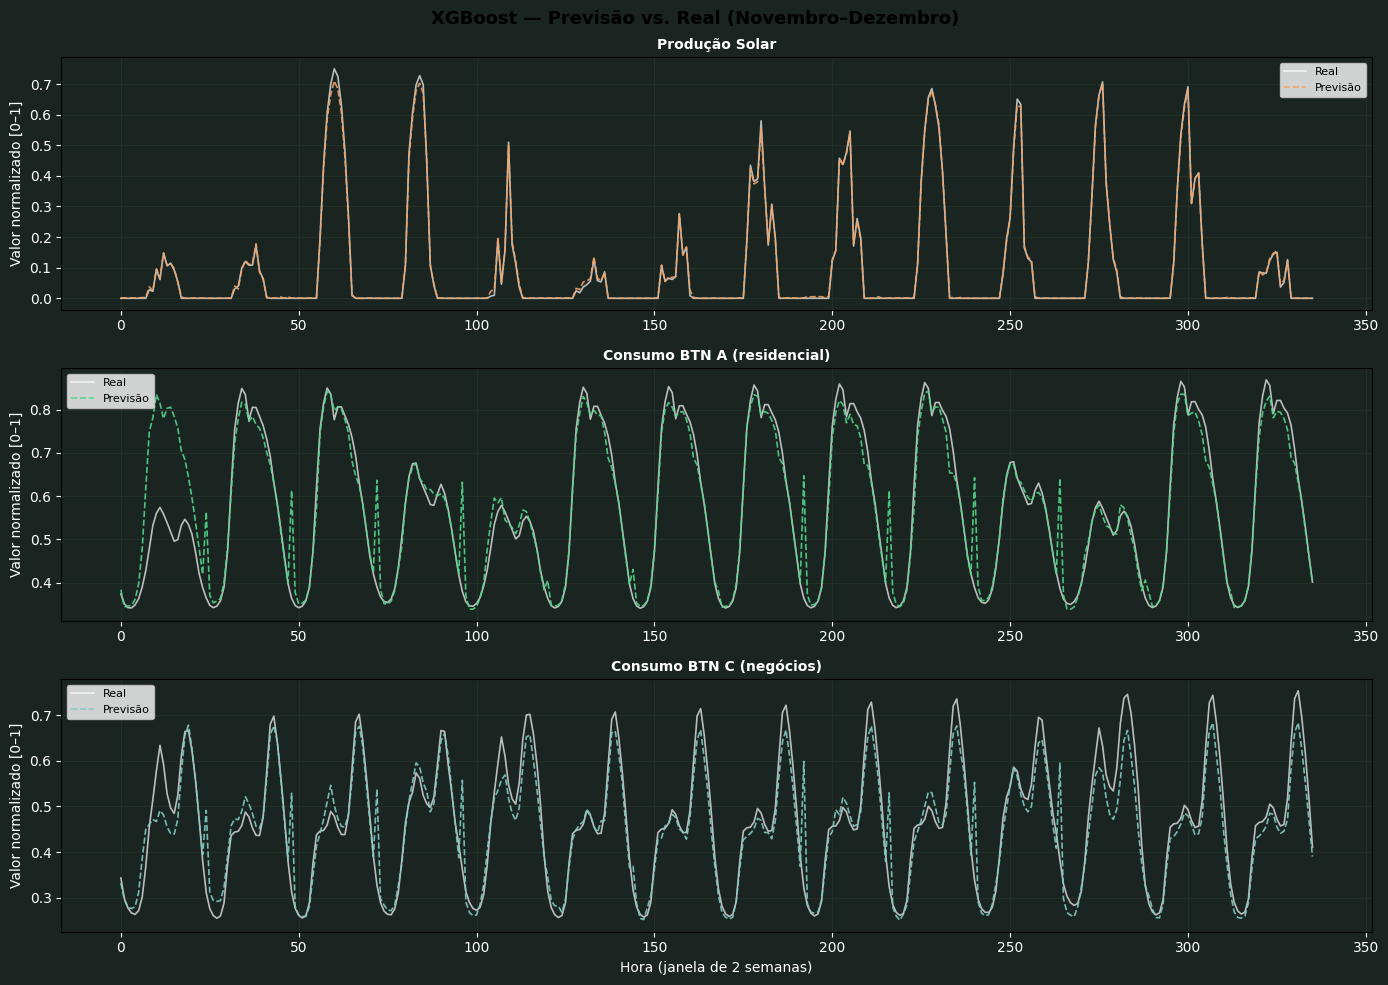

Gráfico guardado: results_ml_preview.png


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle("XGBoost — Previsão vs. Real (Novembro–Dezembro)", fontsize=13, fontweight="bold")

configs = [
    (y_solar_test.values,  pred_solar,  "Produção Solar",          "#F4A261"),
    (y_btn_a_test.values,  pred_btn_a,  "Consumo BTN A (residencial)", "#52D68A"),
    (y_btn_c_test.values,  pred_btn_c,  "Consumo BTN C (negócios)",    "#80CBC4"),
]

# Mostrar apenas 2 semanas para legibilidade
window = 24 * 14

for ax, (real, pred, title, color) in zip(axes, configs):
    ax.plot(real[:window],  label="Real",      color="white",  alpha=0.7, linewidth=1.2)
    ax.plot(pred[:window],  label="Previsão",  color=color,    alpha=0.9, linewidth=1.2, linestyle="--")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_ylabel("Valor normalizado [0–1]")
    ax.legend(fontsize=8)
    ax.set_facecolor("#1a2420")
    ax.grid(color="#2a3a30", linewidth=0.4)

axes[-1].set_xlabel("Hora (janela de 2 semanas)")
fig.patch.set_facecolor("#1a2420")
for ax in axes:
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")

plt.tight_layout()
plt.savefig("../results_ml_preview.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Gráfico guardado: results_ml_preview.png")

## 5. Gerar previsões para 8 760 horas e guardar outputs

In [6]:
# Gerar previsões para o ano completo (todas as 8760 horas)
X_full = df[FEATURES]

pred_solar_full = np.clip(model_solar.predict(X_full), 0, 1).astype(np.float32)
pred_btn_a_full = np.clip(model_btn_a.predict(X_full), 0, 1).astype(np.float32)
pred_btn_c_full = np.clip(model_btn_c.predict(X_full), 0, 1).astype(np.float32)

# Guardar arrays — substituem os .npy da Fase 1 no model.py
np.save(OUTPUT_DIR / "solar_curve_ml.npy",       pred_solar_full)
np.save(OUTPUT_DIR / "consumption_curve_ml_a.npy", pred_btn_a_full)
np.save(OUTPUT_DIR / "consumption_curve_ml_c.npy", pred_btn_c_full)

print("Arrays ML guardados:")
print(f"  solar_curve_ml.npy          shape={pred_solar_full.shape}")
print(f"  consumption_curve_ml_a.npy  shape={pred_btn_a_full.shape}")
print(f"  consumption_curve_ml_c.npy  shape={pred_btn_c_full.shape}")

# Sumário comparativo — sintético vs. ML
print("\nComparação de médias (sintético vs. ML):")
print(f"  Solar    — sintético: {df['solar_norm'].mean():.4f}  |  ML: {pred_solar_full.mean():.4f}")
print(f"  BTN A    — sintético: {df['BTN_A_norm'].mean():.4f}  |  ML: {pred_btn_a_full.mean():.4f}")
print(f"  BTN C    — sintético: {df['BTN_C_norm'].mean():.4f}  |  ML: {pred_btn_c_full.mean():.4f}")

Arrays ML guardados:
  solar_curve_ml.npy          shape=(8760,)
  consumption_curve_ml_a.npy  shape=(8760,)
  consumption_curve_ml_c.npy  shape=(8760,)

Comparação de médias (sintético vs. ML):
  Solar    — sintético: 0.1690  |  ML: 0.1692
  BTN A    — sintético: 0.5945  |  ML: 0.5910
  BTN C    — sintético: 0.4831  |  ML: 0.4690


## 6. Integração com o modelo Mesa

In [7]:
# Verificação final — confirmar que os arrays são compatíveis com model.py
import sys
sys.path.append("../src")
from model import EnergyCommunity, SHARING_MODES

# Carregar arrays ML
SOLAR_ML = np.load(OUTPUT_DIR / "solar_curve_ml.npy")
BTN_A_ML = np.load(OUTPUT_DIR / "consumption_curve_ml_a.npy")
BTN_C_ML = np.load(OUTPUT_DIR / "consumption_curve_ml_c.npy")

# Monkey-patch das funções sintéticas — substituir por ML
import model as cer_model

def solar_profile_ml(n_hours=8760, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    noise = rng.uniform(0.92, 1.08, size=n_hours)
    return np.clip(SOLAR_ML * noise, 0, 1)

def consumption_profile_ml(n_hours=8760, profile_type="residential", rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    base = BTN_A_ML if profile_type == "residential" else BTN_C_ML
    noise = rng.uniform(0.93, 1.07, size=n_hours)
    return np.clip(base * noise, 0, 1)

# Substituir funções no módulo
cer_model.solar_profile       = solar_profile_ml
cer_model.consumption_profile = consumption_profile_ml

# Correr simulação de teste com perfis ML (100 horas para verificação rápida)
model_test = EnergyCommunity(
    n_members      = 30,
    prosumer_ratio = 0.5,
    sharing_mode   = "proportional",
    n_hours        = 100,
    rng            = 42,
)
summary = model_test.run()

print("✓ Simulação Mesa com perfis ML correu com sucesso\n")
print(f"  Autoconsumo colectivo : {summary['self_consumption_rate']:.1%}")
print(f"  Auto-suficiência      : {summary['self_sufficiency_rate']:.1%}")
print(f"  Poupança média        : {summary['avg_savings_eur']:.2f} €")

✓ Simulação Mesa com perfis ML correu com sucesso

  Autoconsumo colectivo : 63.6%
  Auto-suficiência      : 8.7%
  Poupança média        : 2.24 €


## 7. Análise Comparativa — Sintético vs. ML

In [8]:
# Simulação A — perfis sintéticos (baseline original)
cer_model.solar_profile       = cer_model.__wrapped_solar__       = __import__('model').solar_profile
cer_model.consumption_profile = cer_model.__wrapped_consumption__ = __import__('model').consumption_profile

# Reimportar modelo limpo para garantir funções originais
import importlib
import model as cer_model_clean
importlib.reload(cer_model_clean)

print("A correr simulação com perfis SINTÉTICOS...")
model_synthetic = cer_model_clean.EnergyCommunity(
    n_members      = 30,
    prosumer_ratio = 0.5,
    sharing_mode   = "proportional",
    n_hours        = 8760,
    rng            = 42,
)
summary_synthetic = model_synthetic.run()
print("  ✓ Concluído\n")

# Simulação B — perfis ML
cer_model_clean.solar_profile       = solar_profile_ml
cer_model_clean.consumption_profile = consumption_profile_ml

print("A correr simulação com perfis ML...")
model_ml = cer_model_clean.EnergyCommunity(
    n_members      = 30,
    prosumer_ratio = 0.5,
    sharing_mode   = "proportional",
    n_hours        = 8760,
    rng            = 42,
)
summary_ml = model_ml.run()
print("  ✓ Concluído\n")

# Tabela comparativa
metrics = [
    "self_consumption_rate",
    "self_sufficiency_rate",
    "total_production_kWh",
    "total_shared_kWh",
    "total_grid_export_kWh",
    "total_grid_import_kWh",
    "avg_savings_eur",
]

df_compare = pd.DataFrame({
    "Sintético": [summary_synthetic[m] for m in metrics],
    "ML"        : [summary_ml[m]        for m in metrics],
}, index=metrics)

df_compare["Δ absoluto"] = df_compare["ML"] - df_compare["Sintético"]
df_compare["Δ relativo"] = ((df_compare["ML"] - df_compare["Sintético"]) / df_compare["Sintético"] * 100).round(2).astype(str) + "%"

print(df_compare.to_string())

A correr simulação com perfis SINTÉTICOS...
  ✓ Concluído

A correr simulação com perfis ML...
  ✓ Concluído

                         Sintético           ML  Δ absoluto Δ relativo
self_consumption_rate       0.5299       0.5828      0.0529      9.98%
self_sufficiency_rate       0.1762       0.1592     -0.0170     -9.65%
total_production_kWh    59411.1000   61853.7000   2442.6000      4.11%
total_shared_kWh        31481.6000   36049.4000   4567.8000     14.51%
total_grid_export_kWh   27929.5000   25804.3000  -2125.2000     -7.61%
total_grid_import_kWh  114689.0000  147132.0000  32443.0000     28.29%
avg_savings_eur           248.8100     329.2000     80.3900     32.31%


### Visualização comparativa dos outcomes

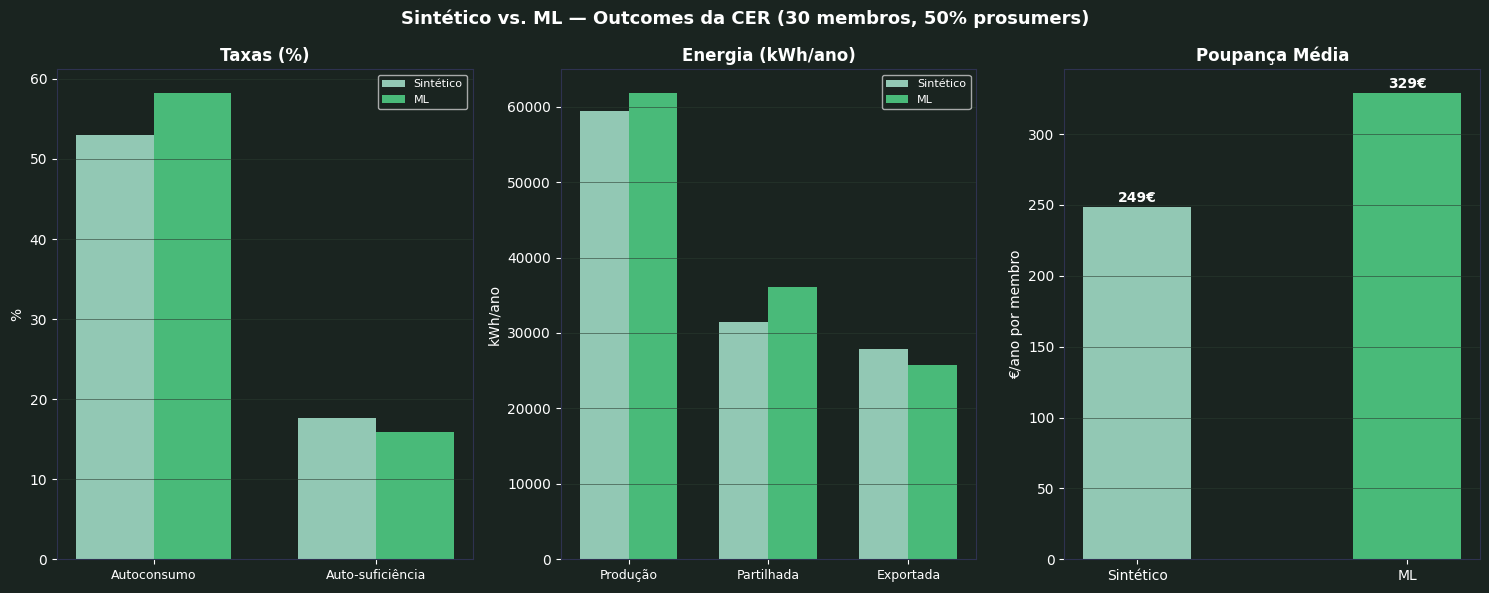

Gráfico guardado: results_comparison.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle("Sintético vs. ML — Outcomes da CER (30 membros, 50% prosumers)",
             fontsize=13, fontweight="bold", color="white")
fig.patch.set_facecolor("#1a2420")

DARK_BG = "#1a2420"
COLORS  = {"Sintético": "#A8E6CF", "ML": "#52D68A"}

# Painel 1 — Taxas (autoconsumo e auto-suficiência)
ax = axes[0]
ax.set_facecolor(DARK_BG)
labels = ["Autoconsumo", "Auto-suficiência"]
vals_s = [summary_synthetic["self_consumption_rate"] * 100,
          summary_synthetic["self_sufficiency_rate"]  * 100]
vals_m = [summary_ml["self_consumption_rate"] * 100,
          summary_ml["self_sufficiency_rate"]  * 100]
x = np.arange(len(labels))
w = 0.35
ax.bar(x - w/2, vals_s, w, label="Sintético", color=COLORS["Sintético"], alpha=0.85)
ax.bar(x + w/2, vals_m, w, label="ML",        color=COLORS["ML"],        alpha=0.85)
ax.set_ylabel("%", color="white")
ax.set_title("Taxas (%)", color="white", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels, color="white", fontsize=9)
ax.tick_params(colors="white")
ax.legend(fontsize=8, facecolor=DARK_BG, labelcolor="white")
ax.grid(color="#2a3a30", linewidth=0.4, axis="y")

# Painel 2 — Energia (produção, partilha, exportação)
ax = axes[1]
ax.set_facecolor(DARK_BG)
labels2 = ["Produção", "Partilhada", "Exportada"]
vals_s2 = [summary_synthetic["total_production_kWh"],
           summary_synthetic["total_shared_kWh"],
           summary_synthetic["total_grid_export_kWh"]]
vals_m2 = [summary_ml["total_production_kWh"],
           summary_ml["total_shared_kWh"],
           summary_ml["total_grid_export_kWh"]]
x2 = np.arange(len(labels2))
ax.bar(x2 - w/2, vals_s2, w, label="Sintético", color=COLORS["Sintético"], alpha=0.85)
ax.bar(x2 + w/2, vals_m2, w, label="ML",        color=COLORS["ML"],        alpha=0.85)
ax.set_ylabel("kWh/ano", color="white")
ax.set_title("Energia (kWh/ano)", color="white", fontweight="bold")
ax.set_xticks(x2)
ax.set_xticklabels(labels2, color="white", fontsize=9)
ax.tick_params(colors="white")
ax.legend(fontsize=8, facecolor=DARK_BG, labelcolor="white")
ax.grid(color="#2a3a30", linewidth=0.4, axis="y")

# Painel 3 — Poupança média
ax = axes[2]
ax.set_facecolor(DARK_BG)
vals_s3 = summary_synthetic["avg_savings_eur"]
vals_m3 = summary_ml["avg_savings_eur"]
bars = ax.bar(["Sintético", "ML"], [vals_s3, vals_m3],
              color=[COLORS["Sintético"], COLORS["ML"]], alpha=0.85, width=0.4)
ax.set_ylabel("€/ano por membro", color="white")
ax.set_title("Poupança Média", color="white", fontweight="bold")
ax.tick_params(colors="white")
ax.grid(color="#2a3a30", linewidth=0.4, axis="y")
for bar, val in zip(bars, [vals_s3, vals_m3]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f"{val:.0f}€", ha="center", color="white", fontsize=10, fontweight="bold")

for ax in axes:
    for spine in ax.spines.values():
        spine.set_edgecolor("#2e3250")

plt.tight_layout()
plt.savefig("../results_comparison.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Gráfico guardado: results_comparison.png")